# Analise sequencial de similatidade entre cortes centrais

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
def parse_log(log_data):
    records = []
    current_record = {}

    for line in log_data.strip().split('\n'):
        line = line.strip()
        if line.startswith('ID da Imagem:'):
            current_record['ID da Imagem'] = line.split(': ')[1]
        elif line.startswith('Quantidade de cortes B avaliados:'):
            current_record['Cortes Avaliados'] = int(line.split(': ')[1])
        elif line.startswith('Tempo de Leitura Total (A+B):'):
            current_record['Tempo Leitura Total (s)'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo Medio Calculo SSIM (por slice):'):
            current_record['Tempo Medio SSIM (s)'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo de Busca (SSIM loop):'):
            current_record['Tempo Busca (s)'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo Total do Processo:'):
            current_record['Tempo Total (s)'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Melhor Slice (Z):'):
            current_record['Melhor Slice'] = int(line.split(': ')[1])
        elif line.startswith('SSIM Maximo Encontrado:'):
            current_record['SSIM Maximo'] = float(line.split(': ')[1])
            records.append(current_record)
            current_record = {}
    return pd.DataFrame(records)

In [3]:
file_path = "data/log.txt"
if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        log_content = f.read()
    data_records = parse_log(log_content)
    df = pd.DataFrame(data_records)
else:
    print(f"Arquivo {file_path} não encontrado.")

In [4]:
df.columns

Index(['ID da Imagem', 'Cortes Avaliados', 'Tempo Leitura Total (s)',
       'Tempo Medio SSIM (s)', 'Tempo Busca (s)', 'Tempo Total (s)',
       'Melhor Slice', 'SSIM Maximo'],
      dtype='str')

In [5]:
df.head()

,ID da Imagem,Cortes Avaliados,Tempo Leitura Total (s),Tempo Medio SSIM (s),Tempo Busca (s),Tempo Total (s),Melhor Slice,SSIM Maximo
0,TRV1P1,280,0.842813,0.020312,5.751038,6.595070,198,0.869973
1,TRV1P1,280,0.922328,0.021162,5.992625,6.915534,198,0.869973
2,TRV1P1,280,0.832339,0.019927,5.639376,6.472805,198,0.869973
3,TRV1P1,280,0.846450,0.020049,5.675158,6.522319,198,0.869973
4,TRV1P1,280,0.833923,0.018880,5.343397,6.178350,198,0.869973


In [6]:
df[["Cortes Avaliados", "Tempo Leitura Total (s)", "Tempo Medio SSIM (s)", 
    "Tempo Busca (s)", "Tempo Total (s)"]].describe()

,Cortes Avaliados,Tempo Leitura Total (s),Tempo Medio SSIM (s),Tempo Busca (s),Tempo Total (s)
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,191.034722,0.980282,0.018909,3.673387,4.654632
std,164.331586,0.323727,0.001357,3.222739,3.367407
min,36.000000,0.472004,0.017113,0.642870,1.345669
25%,47.000000,0.726296,0.018226,0.885790,1.842401
50%,115.500000,0.924660,0.018604,2.380919,3.484640
75%,296.250000,1.186934,0.019124,5.590639,6.533529
max,640.000000,2.807588,0.036704,13.747070,16.171397


C:\Users\evera\AppData\Local\Temp\ipykernel_25852\4071321008.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


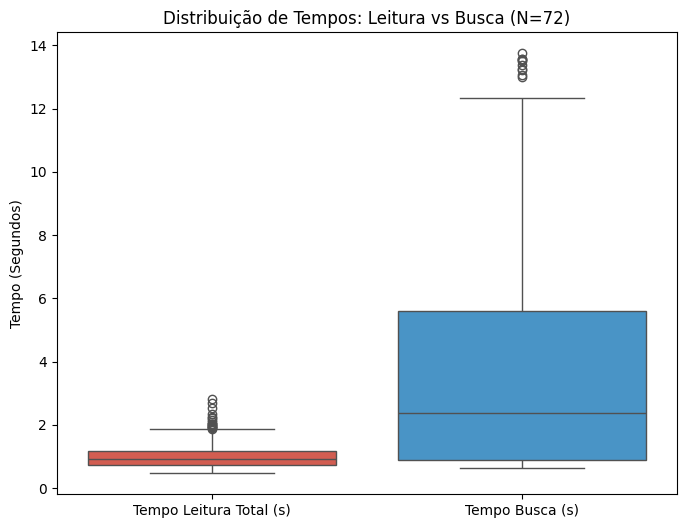

In [7]:
plt.figure(figsize=(8, 6))

df_melted = df[['Tempo Leitura Total (s)', 'Tempo Busca (s)']].melt(
    var_name='Etapa do Processamento', 
    value_name='Tempo (s)'
)

sns.boxplot(
    data=df_melted,
    x='Etapa do Processamento',
    y='Tempo (s)',
    palette=['#e74c3c', '#3498db']
)

plt.title('Distribuição de Tempos: Leitura vs Busca (N=72)')
plt.ylabel('Tempo (Segundos)')
plt.xlabel('')
plt.show()

C:\Users\evera\AppData\Local\Temp\ipykernel_25852\2940670578.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


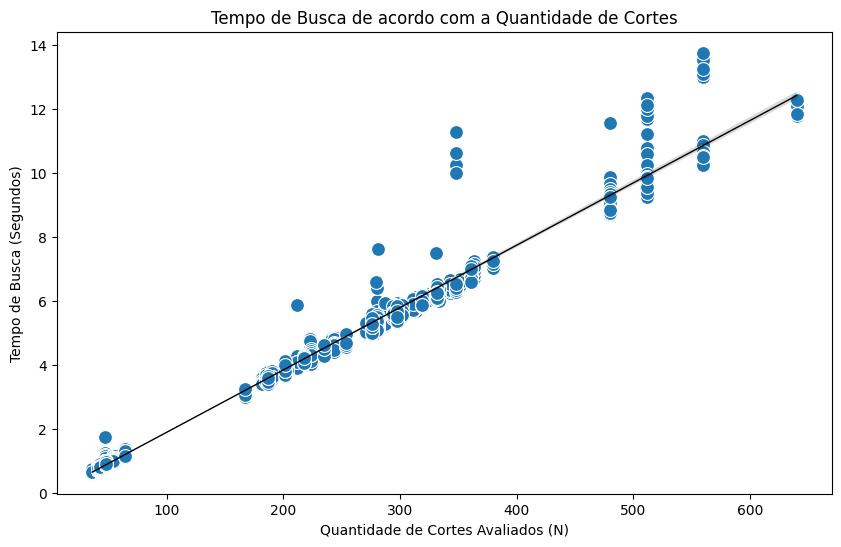

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Cortes Avaliados', 
    y='Tempo Busca (s)', 
    s=100, # tamanho das bolinhas
    palette='deep',
    legend=False
)

sns.regplot(
    data=df,
    x='Cortes Avaliados',
    y='Tempo Busca (s)',
    scatter=False,
    color='black',
    line_kws={'linewidth': 1}
)

plt.title('Tempo de Busca de acordo com a Quantidade de Cortes')
plt.ylabel('Tempo de Busca (Segundos)')
plt.xlabel('Quantidade de Cortes Avaliados (N)')
plt.show()

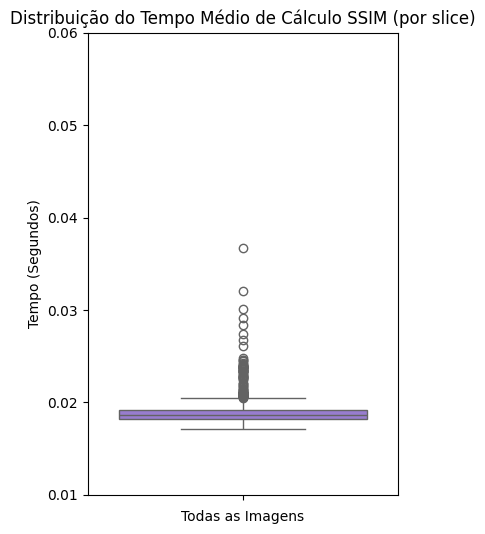

In [9]:
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df,
    y='Tempo Medio SSIM (s)', 
    color='mediumpurple'
)

plt.title('Distribuição do Tempo Médio de Cálculo SSIM (por slice)')
plt.ylabel('Tempo (Segundos)')
plt.xlabel('Todas as Imagens')
plt.ylim(0.01, 0.06)
plt.show()
